# Évaluation de checkpoints fixes (ablation)
Ce notebook évalue des checkpoints fixes et trace uniquement les figures d'ablation utiles au papier : discharge forcing, pushforward, multimesh et distribution des longueurs d'arêtes.


In [1]:
import os
import sys
import pickle

import dgl
import matplotlib.pyplot as plt
import numpy as np
import torch
from matplotlib.lines import Line2D

ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if ROOT not in sys.path:
    sys.path.append(ROOT)

from python.create_dgl_dataset import TelemacDataset, TelemacDatasetWithQ
from python.eval_rollout import (
    build_model as _build_rollout_model,
    build_rollout_context,
    create_rollout_state,
    denormalize_state,
    load_model_checkpoint as _load_rollout_model_checkpoint,
    rollout_step,
)
from python.python_code.data_manip.extraction.telemac_file import TelemacFile

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

In [8]:
# =====================
# Parametres utilisateur
# =====================
DATA_DIRS = {
    "multimesh": "/work/m24046/m24046mrcr/dataset_x8_avec_ts/shortx8/Multimesh_8_32.bin",
    "normal": "/work/m24046/m24046mrcr/dataset_x8_avec_ts/shortx8/Mesh8_base.bin",
}
DEFAULT_MESH = "multimesh"
DT_SECONDS = 1800.0

TEST_EVENTS = [
    'Group_1_peak_2600',
    'Group_2_peak_1000',
    'Group_2_peak_1200',
    'Group_2_peak_1600',
    'Group_4_peak_2000',
    'Group_1_peak_1200',
    'Group_1_peak_2400',
    'Group_3_peak_3400',
    'Group_1_peak_1400',
    'Group_1_peak_2000',
    'Group_1_peak_2200',
    'Group_2_peak_3600',
    'Group_3_peak_2200',
    "Group_3_peak_2800",
    "Group_4_peak_1200",
    "Group_4_peak_3000",
]

def build_dynamic_path(event_name):
    return (
        "/work/m24046/m24046mrcr/dataset_x8_avec_ts/shortx8/"
        f"{event_name}_{event_name}_0_35-64_interpolated.pkl"
    )

def build_hydro_path(event_name):
    return (
        "/work/m24046/m24046mrcr/dataset_x8_avec_ts/hydrogrammes/"
        f"generated_hydrographs_{event_name}.liq"
    )

DYNAMIC_DIR = [build_dynamic_path(event_name) for event_name in TEST_EVENTS]
HYDRO_DIR = [build_hydro_path(event_name) for event_name in TEST_EVENTS]

METHODS = [
    {
        "name": "Experiment 1",
        "ckpt_dir": "/work/m24046/m24046mrcr/paper/Experience1/Seed0/",
        "epoch": 900,
        "use_q_feature": False,
        "mesh": "normal",
    },
    {
        "name": "Experiment 2",
        "ckpt_dir": "/work/m24046/m24046mrcr/paper/Experience7/Seed0/",
        "epoch": 900,
        "use_q_feature": True,
        "mesh": "normal",
    },
    {
        "name": "Experiment 3",
        "ckpt_dir": "/work/m24046/m24046mrcr/paper/Experience9/Seed0/",
        "epoch": 900,
        "use_q_feature": True,
        "mesh": "normal",
    },
    {
        "name": "Experiment 4",
        "ckpt_dir": "/work/m24046/m24046mrcr/paper/Experience2/Seed0/",
        "epoch": 900,
        "use_q_feature": False,
        "mesh": "multimesh",
    },
    {
        "name": "Experiment 5",
        "ckpt_dir": "/work/m24046/m24046mrcr/paper/Experience8/Seed0/",
        "epoch": 900,
        "use_q_feature": True,
        "mesh": "multimesh",
    },
    {
        "name": "Experiment 6",
        "ckpt_dir": "/work/m24046/m24046mrcr/paper/Experience10/Seed0/",
        "epoch": 900,
        "use_q_feature": True,
        "mesh": "multimesh",
    },
]

NUM_EDGE_FEATURES = 3
NUM_OUTPUT_FEATURES = 3
MP_LAYERS = 10
DO_CONCAT_TRICK = True
NUM_PROCESSOR_CHECKPOINT_SEGMENTS = 0

REQUESTED_MAX_HOURS = 40
HOUR_IN_STEPS = max(1, int(round(3600.0 / DT_SECONDS)))
MAX_SEQUENCES = 205

EXPERIENCE_COLORS = {
    "Experiment 1": "#1f77b4",
    "Experiment 2": "#ff7f0e",
    "Experiment 3": "#2ca02c",
    "Experiment 4": "#d62728",
    "Experiment 5": "#9467bd",
    "Experiment 6": "#8c564b",
}

Q_ABLATION_PANELS = [
    {
        "title": "Standard mesh",
        "runs": {
            "Experiment 1": "Experiment 1@900",
            "Experiment 2": "Experiment 2@900",
        },
    },
    {
        "title": "Multimesh",
        "runs": {
            "Experiment 4": "Experiment 4@900",
            "Experiment 5": "Experiment 5@900",
        },
    },
]

PF_ABLATION_PANELS = [
    {
        "title": "Standard mesh",
        "runs": {
            "Experiment 2": "Experiment 2@900",
            "Experiment 3": "Experiment 3@900",
        },
    },
    {
        "title": "Multimesh",
        "runs": {
            "Experiment 5": "Experiment 5@900",
            "Experiment 6": "Experiment 6@900",
        },
    },
]

MULTIMESH_ABLATION_PANELS = [
    {
        "title": "With Q / Without PF",
        "runs": {
            "Experiment 2": "Experiment 2@900",
            "Experiment 5": "Experiment 5@900",
        },
    },
    {
        "title": "With Q / With PF",
        "runs": {
            "Experiment 3": "Experiment 3@900",
            "Experiment 6": "Experiment 6@900",
        },
    },
]

HIGH_RES_MESH_PATH = "/work/m24046/m24046mrcr/results_data_30min/maillage_3.slf"


In [3]:
def get_dynamic_length(file_path):
    with open(file_path, "rb") as f:
        return len(pickle.load(f))

dynamic_lengths = [get_dynamic_length(path) for path in DYNAMIC_DIR]
min_num_samples = min(dynamic_lengths)
max_available_step = max(1, min_num_samples - 1)
available_max_hours = max_available_step // HOUR_IN_STEPS

if available_max_hours < 1:
    raise ValueError("Aucun horizon horaire disponible avec les fichiers DYNAMIC_DIR courants.")

if available_max_hours < REQUESTED_MAX_HOURS:
    print(
        f"Attention: au moins un fichier test ne contient que {min_num_samples} echantillons. "
        f"Le notebook evaluera donc {available_max_hours} heures au lieu de {REQUESTED_MAX_HOURS}."
    )

MAX_HOURS = available_max_hours
HORIZONS_STEPS = [h * HOUR_IN_STEPS for h in range(1, MAX_HOURS + 1)]
print(
    f"min_num_samples={min_num_samples} | MAX_HOURS={MAX_HOURS} | "
    f"max_horizon_step={HORIZONS_STEPS[-1]}"
)


Attention: au moins un fichier test ne contient que 30 echantillons. Le notebook evaluera donc 14 heures au lieu de 40.
min_num_samples=30 | MAX_HOURS=14 | max_horizon_step=28


In [4]:
# =====================
# Evaluation
# =====================
def build_model(num_input_features):
    return _build_rollout_model(
        num_input_features=num_input_features,
        num_edge_features=NUM_EDGE_FEATURES,
        num_output_features=NUM_OUTPUT_FEATURES,
        mp_layers=MP_LAYERS,
        do_concat_trick=DO_CONCAT_TRICK,
        num_processor_checkpoint_segments=NUM_PROCESSOR_CHECKPOINT_SEGMENTS,
    )

def build_dataset(sequence_length, ckpt_dir, use_q_feature, data_dir, overlap=1, split="test", dynamic_dir=None, hydro_dir=None):
    dynamic_files = dynamic_dir if dynamic_dir is not None else DYNAMIC_DIR
    hydro_files = hydro_dir if hydro_dir is not None else HYDRO_DIR

    if use_q_feature:
        if len(hydro_files) == 0:
            raise ValueError("use_q_feature=True mais hydro_dir est vide.")
        if len(hydro_files) != len(dynamic_files):
            raise ValueError(
                f"hydro_dir ({len(hydro_files)}) et dynamic_dir ({len(dynamic_files)}) doivent avoir la meme longueur."
            )
        return TelemacDatasetWithQ(
            name=f"eval_{split}",
            data_dir=data_dir,
            dynamic_data_files=dynamic_files,
            hydro_data_files=hydro_files,
            split=split,
            ckpt_path=ckpt_dir,
            normalize=True,
            sequence_length=sequence_length,
            overlap=overlap,
            dt_seconds=DT_SECONDS,
        )

    return TelemacDataset(
        name=f"eval_{split}",
        data_dir=data_dir,
        dynamic_data_files=dynamic_files,
        split=split,
        ckpt_path=ckpt_dir,
        normalize=True,
        sequence_length=sequence_length,
        overlap=overlap,
    )

def summarize_l1(agg, horizons_steps):
    summary = {}
    for step in horizons_steps:
        if len(agg[step]) == 0:
            continue

        l1_stack = np.stack(agg[step], axis=0)
        summary[step] = {
            "l1_mean": np.nanmean(l1_stack, axis=0).tolist(),
            "l1_std": np.nanstd(l1_stack, axis=0).tolist(),
        }
    return summary

def evaluate_model(model, ds, horizons_steps, use_q_feature, max_sequences=10):
    rollout_context = build_rollout_context(ds, device=device, use_q_feature=use_q_feature)
    agg = {step: [] for step in horizons_steps}
    step_set = set(horizons_steps)
    nseq = min(max_sequences, len(ds))
    max_h = max(horizons_steps)

    for idx in range(nseq):
        graphs = ds[idx]
        if len(graphs) <= max_h:
            continue

        rollout_state = create_rollout_state(graphs[0], rollout_context)

        for t in range(max_h):
            x_gt_full_n = graphs[t + 1].ndata["x"][:, rollout_context.dyn_start:rollout_context.dyn_start + rollout_context.dyn_len].to(device)
            x_gt = denormalize_state(x_gt_full_n[:, :3], rollout_context)
            q_t1_n = x_gt_full_n[:, 3:4] if use_q_feature else None

            step_result = rollout_step(
                model,
                rollout_state,
                rollout_context,
                x_gt=x_gt,
                q_t1_n=q_t1_n,
            )

            step = t + 1
            if step in step_set:
                l1 = torch.mean(
                    torch.abs(step_result.predicted_state - step_result.target_state),
                    dim=0,
                ).detach().cpu().numpy()
                agg[step].append(l1)

            rollout_state = step_result.next_state

    return summarize_l1(agg, horizons_steps)

def evaluate_single_checkpoint(method, horizons_steps, max_sequences=10):
    sequence_length = max(horizons_steps) + 1
    data_dir = method.get("data_dir", DATA_DIRS[method.get("mesh", DEFAULT_MESH)])
    ds = build_dataset(
        sequence_length=sequence_length,
        overlap=1,
        split="test",
        ckpt_dir=method["ckpt_dir"],
        use_q_feature=method["use_q_feature"],
        data_dir=data_dir,
        dynamic_dir=method.get("dynamic_dir", DYNAMIC_DIR),
        hydro_dir=method.get("hydro_dir", HYDRO_DIR),
    )

    if len(ds) == 0:
        raise ValueError(
            f"Aucune sequence disponible pour sequence_length={sequence_length}. "
            "Reduis REQUESTED_MAX_HOURS ou utilise des fichiers dynamiques plus longs."
        )

    expected_input_features = ds.base_graph.ndata["static"].shape[1] + (4 if method["use_q_feature"] else 3)
    model = build_model(expected_input_features)
    _load_rollout_model_checkpoint(model, method["ckpt_dir"], method["epoch"], device=device)

    return evaluate_model(
        model,
        ds,
        horizons_steps,
        use_q_feature=method["use_q_feature"],
        max_sequences=max_sequences,
    )

def evaluate_fixed_methods(methods, horizons_steps, max_sequences=10):
    evaluations = {}
    for method in methods:
        run_name = f"{method['name']}@{method['epoch']}"
        evaluations[run_name] = evaluate_single_checkpoint(
            method,
            horizons_steps=horizons_steps,
            max_sequences=max_sequences,
        )
    return evaluations


In [5]:
# =====================
# Lancement de l'evaluation
# =====================
evaluations = evaluate_fixed_methods(
    METHODS,
    horizons_steps=HORIZONS_STEPS,
    max_sequences=MAX_SEQUENCES,
)


Loading normalization statistics...


[11:18:48 - checkpoint - INFO] Loaded model state dictionary /work/m24046/m24046mrcr/paper/Experience1/Seed0/MeshGraphNet.0.900.mdlus to device cuda
[11:18:48 - checkpoint - INFO] Loaded checkpoint file /work/m24046/m24046mrcr/paper/Experience1/Seed0/checkpoint.0.900.pt to device cuda


Loading normalization statistics...


[11:18:56 - checkpoint - INFO] Loaded model state dictionary /work/m24046/m24046mrcr/paper/Experience7/Seed0/MeshGraphNet.0.900.mdlus to device cuda
[11:18:56 - checkpoint - INFO] Loaded checkpoint file /work/m24046/m24046mrcr/paper/Experience7/Seed0/checkpoint.0.900.pt to device cuda


Loading normalization statistics...


...

[11:19:11 - checkpoint - INFO] Loaded model state dictionary /work/m24046/m24046mrcr/paper/Experience2/Seed0/MeshGraphNet.0.900.mdlus to device cuda
[11:19:11 - checkpoint - INFO] Loaded checkpoint file /work/m24046/m24046mrcr/paper/Experience2/Seed0/checkpoint.0.900.pt to device cuda


Loading normalization statistics...


[11:19:18 - checkpoint - INFO] Loaded model state dictionary /work/m24046/m24046mrcr/paper/Experience8/Seed0/MeshGraphNet.0.900.mdlus to device cuda
[11:19:18 - checkpoint - INFO] Loaded checkpoint file /work/m24046/m24046mrcr/paper/Experience8/Seed0/checkpoint.0.900.pt to device cuda


Loading normalization statistics...


[11:19:26 - checkpoint - INFO] Loaded model state dictionary /work/m24046/m24046mrcr/paper/Experience10/Seed0/MeshGraphNet.0.900.mdlus to device cuda
[11:19:26 - checkpoint - INFO] Loaded checkpoint file /work/m24046/m24046mrcr/paper/Experience10/Seed0/checkpoint.0.900.pt to device cuda


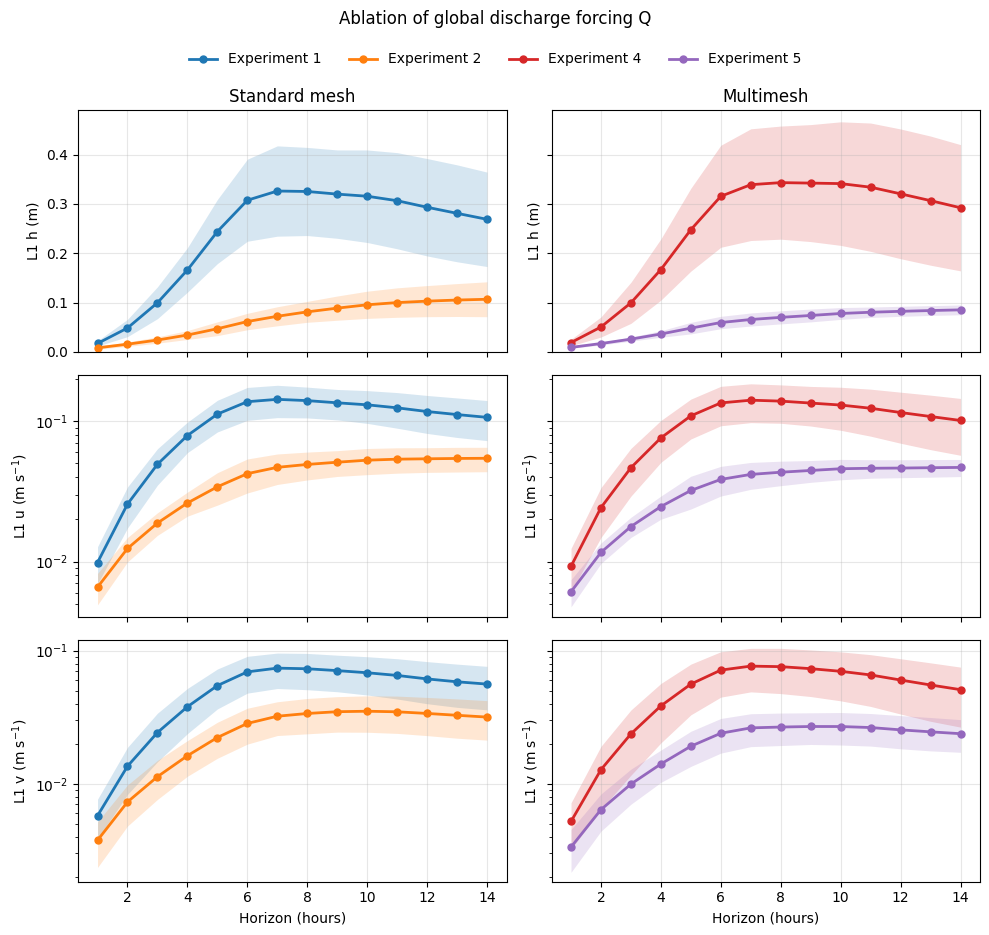

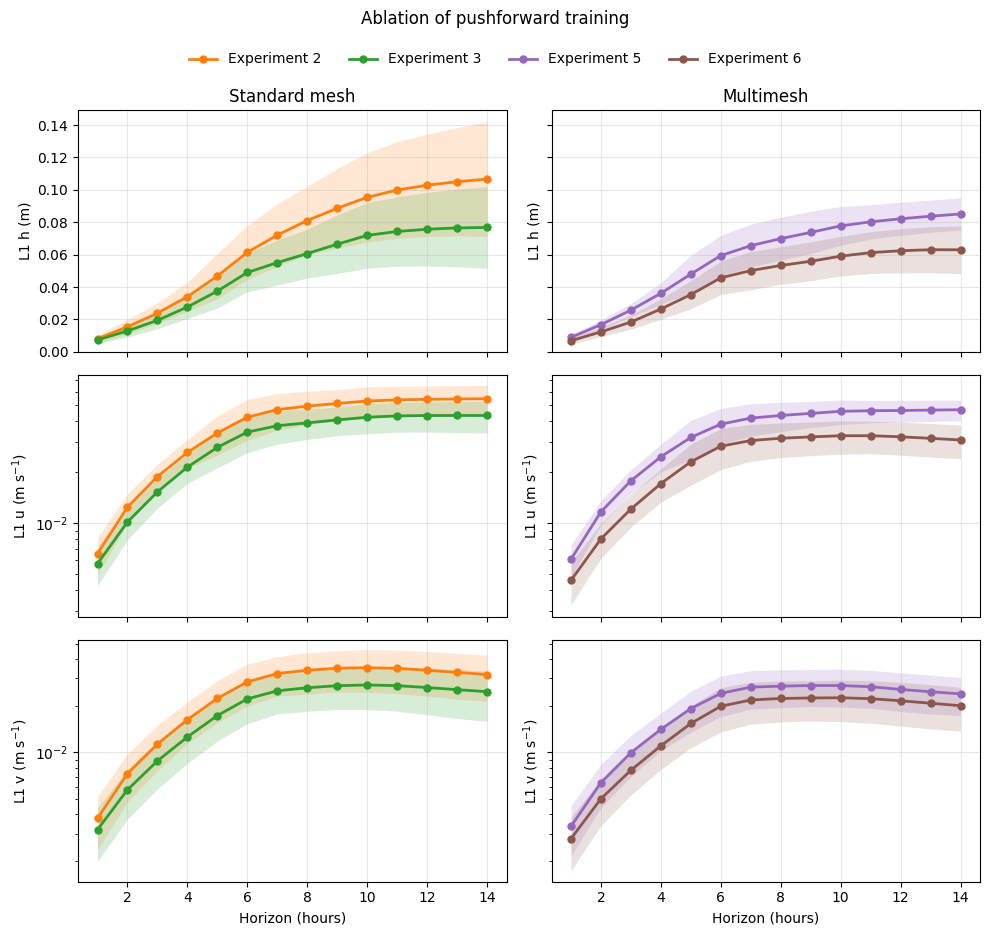

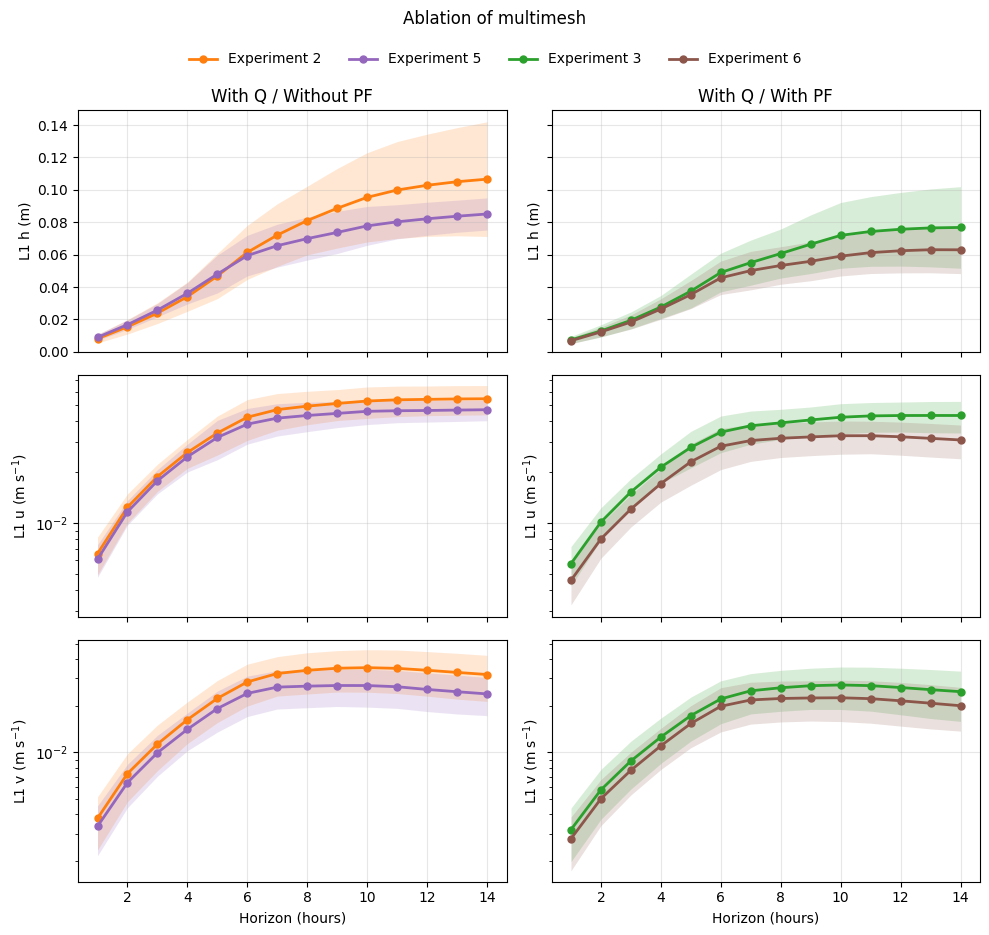

In [9]:
# =====================
# Figures d'ablation
# =====================
def _style_for_experience(label):
    return {
        "color": EXPERIENCE_COLORS[label],
        "marker": "o",
        "linewidth": 2,
        "markersize": 5,
    }

def _build_legend_handles(labels):
    return [Line2D([0], [0], label=label, **_style_for_experience(label)) for label in labels]

def _extract_l1_mean_std(evaluations, run_name, horizons_steps, comp_idx, positive_only=False):
    summary = evaluations[run_name]
    mean_vals = np.array(
        [summary.get(step, {}).get("l1_mean", [np.nan, np.nan, np.nan])[comp_idx] for step in horizons_steps],
        dtype=float,
    )
    std_vals = np.array(
        [summary.get(step, {}).get("l1_std", [np.nan, np.nan, np.nan])[comp_idx] for step in horizons_steps],
        dtype=float,
    )

    if positive_only:
        mask = mean_vals <= 0.0
        mean_vals[mask] = np.nan
        std_vals[mask] = np.nan

    return mean_vals, std_vals

def _plot_l1_with_band(ax, hours, mean_vals, std_vals, label, use_log=False):
    style = _style_for_experience(label)
    ax.plot(hours, mean_vals, label=label, **style)
    lower = mean_vals - std_vals
    upper = mean_vals + std_vals
    if use_log:
        lower[lower <= 0.0] = np.nan
    ax.fill_between(hours, lower, upper, color=style["color"], alpha=0.18, linewidth=0)
    return lower, upper

def _row_ylim(row_bounds, use_log=False):
    lowers = [np.nanmin(lower) for lower, _ in row_bounds if lower.size > 0]
    uppers = [np.nanmax(upper) for _, upper in row_bounds if upper.size > 0]
    if not lowers or not uppers:
        return None

    ymin = min(lowers)
    ymax = max(uppers)
    if use_log:
        return ymin * 0.85, ymax * 1.15
    return min(0.0, ymin * 0.95), ymax * 1.05

def plot_ablation_l1(evaluations, horizons_steps, panels, title):
    hours = np.array([step * DT_SECONDS / 3600.0 for step in horizons_steps], dtype=float)
    rows = [
        (0, False, "L1 h (m)"),
        (1, True, r"L1 u (m s$^{-1}$)"),
        (2, True, r"L1 v (m s$^{-1}$)"),
    ]

    fig, axes = plt.subplots(
        3,
        len(panels),
        figsize=(5 * len(panels), 10),
        sharex=True,
        sharey="row",
    )
    if len(panels) == 1:
        axes = np.asarray(axes).reshape(3, 1)

    legend_labels = []
    for row_idx, use_log, ylabel in rows:
        row_bounds = []
        for col_idx, panel in enumerate(panels):
            ax = axes[row_idx, col_idx]
            for exp_label, run_name in panel["runs"].items():
                mean_vals, std_vals = _extract_l1_mean_std(
                    evaluations,
                    run_name,
                    horizons_steps,
                    comp_idx=row_idx,
                    positive_only=use_log,
                )
                lower, upper = _plot_l1_with_band(ax, hours, mean_vals, std_vals, exp_label, use_log=use_log)
                finite_lower = lower[np.isfinite(lower)]
                finite_upper = upper[np.isfinite(upper)]
                if finite_lower.size > 0 and finite_upper.size > 0:
                    row_bounds.append((finite_lower, finite_upper))
                if exp_label not in legend_labels:
                    legend_labels.append(exp_label)

            if row_idx == 0:
                ax.set_title(panel["title"])
            ax.set_ylabel(ylabel)
            ax.grid(True, alpha=0.3)
            if use_log:
                ax.set_yscale("log")
            if row_idx == 2:
                ax.set_xlabel("Horizon (hours)")

        ylim = _row_ylim(row_bounds, use_log=use_log)
        if ylim is not None:
            for ax in axes[row_idx, :]:
                ax.set_ylim(*ylim)

    fig.suptitle(title, y=0.93)
    fig.legend(
        handles=_build_legend_handles(legend_labels),
        loc="upper center",
        bbox_to_anchor=(0.5, 0.90),
        ncol=min(6, len(legend_labels)),
        frameon=False,
    )
    fig.tight_layout(rect=[0, 0, 1, 0.90])
    plt.show()

plot_ablation_l1(
    evaluations,
    HORIZONS_STEPS,
    panels=Q_ABLATION_PANELS,
    title="Ablation of global discharge forcing Q",
)

plot_ablation_l1(
    evaluations,
    HORIZONS_STEPS,
    panels=PF_ABLATION_PANELS,
    title="Ablation of pushforward training",
)

plot_ablation_l1(
    evaluations,
    HORIZONS_STEPS,
    panels=MULTIMESH_ABLATION_PANELS,
    title="Ablation of multimesh",
)


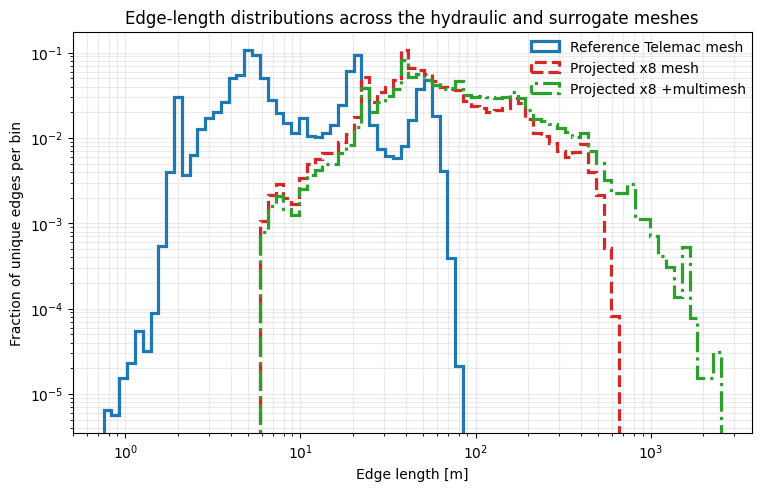

In [7]:
# =====================
# Edge-length distributions
# =====================
GRAPH_PATHS = {
    "Projected x8 mesh": DATA_DIRS["normal"],
    "Projected x8 +multimesh": DATA_DIRS["multimesh"],
}

def unique_edge_lengths_from_telemac(mesh_path):
    mesh = TelemacFile(mesh_path)
    triangles = mesh.tri.triangles
    edges = np.vstack([
        np.sort(triangles[:, [0, 1]], axis=1),
        np.sort(triangles[:, [1, 2]], axis=1),
        np.sort(triangles[:, [2, 0]], axis=1),
    ])
    edges = np.unique(edges, axis=0)

    x = np.asarray(mesh.tri.x)
    y = np.asarray(mesh.tri.y)
    dx = x[edges[:, 0]] - x[edges[:, 1]]
    dy = y[edges[:, 0]] - y[edges[:, 1]]
    return np.sqrt(dx ** 2 + dy ** 2)

def unique_edge_lengths_from_dgl(graph_path):
    graphs, _ = dgl.load_graphs(graph_path)
    graph = graphs[0]
    src, dst = graph.edges()
    src = src.cpu().numpy()
    dst = dst.cpu().numpy()

    mask = src != dst
    undirected = np.sort(np.column_stack([src[mask], dst[mask]]), axis=1)
    _, first_idx = np.unique(undirected, axis=0, return_index=True)
    edge_lengths = graph.edata["x"][:, 2].cpu().numpy()[mask]
    return edge_lengths[np.sort(first_idx)]

length_sets = {
    "Reference Telemac mesh": unique_edge_lengths_from_telemac(HIGH_RES_MESH_PATH),
    **{name: unique_edge_lengths_from_dgl(path) for name, path in GRAPH_PATHS.items()},
}

plot_order = [
    "Reference Telemac mesh",
    "Projected x8 mesh",
    "Projected x8 +multimesh",
]
colors = {
    "Reference Telemac mesh": "#1f77b4",
    "Projected x8 mesh": "#d62728",
    "Projected x8 +multimesh": "#2ca02c",
}
linestyles = {
    "Reference Telemac mesh": "-",
    "Projected x8 mesh": "--",
    "Projected x8 +multimesh": "-.",
}

all_lengths = np.concatenate([length_sets[name] for name in plot_order])
bins = np.geomspace(all_lengths.min(), all_lengths.max(), 80)

fig, ax = plt.subplots(figsize=(7.5, 4.8), constrained_layout=True)
for name in plot_order:
    lengths = length_sets[name]
    weights = np.full(lengths.shape, 1.0 / len(lengths), dtype=float)
    ax.hist(
        lengths,
        bins=bins,
        weights=weights,
        histtype="step",
        linewidth=2.3,
        color=colors[name],
        linestyle=linestyles[name],
        label=name,
    )

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Edge length [m]")
ax.set_ylabel("Fraction of unique edges per bin")
ax.set_title("Edge-length distributions across the hydraulic and surrogate meshes")
ax.grid(True, which="both", alpha=0.25)
ax.legend(frameon=False, loc="upper right", bbox_to_anchor=(1.01, 1.01))
plt.show()
